# FIFA World Cup Results: Exploratory Data Visualization Analysis

## Introduction

The FIFA World Cup has produced decades of match data that can be used to examine trends in team participation, scoring, tournament stages, and host locations. The purpose of this analysis is to explore historical World Cup match results and communicate important patterns through effective data visualizations.

This analysis uses Python and visualization libraries including Pandas, Matplotlib, Seaborn, and Plotly. Six visualizations are used to examine the data from different perspectives, including historical trends, distributions, comparisons, and outliers. The goal is to demonstrate how selecting an appropriate visualization can make patterns within sports data easier to identify and communicate.

## Analytical Questions

This analysis addresses the following questions:

1. Which countries have participated in the greatest number of World Cup matches?
2. How has the average number of goals scored per match changed across World Cup tournaments?
3. What is the distribution of total goals scored in World Cup matches, and are there noticeable high-scoring outliers?
4. How does home-team scoring compare with away-team scoring?
5. Which World Cup tournament stages have the highest average number of goals per match?
6. Which cities have hosted the greatest number of World Cup matches?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Data Preparation
The dataset contains 964 FIFA World Cup matches and 25 variables. The data was examined for missing values and duplicate records, and none were identified. Numeric variables such as year, home goals, away goals, total goals, and goal difference were already stored using appropriate numeric data types. The Date column was converted from an object to a datetime datatype to support time-based analysis. Existing derived variables, including TotalGoals, GoalDifference, Winner, and Decade, were also reviewed before beginning the visualization analysis.

In [2]:
df = pd.read_csv("Data/WorldCupResults.csv")
df.head()

,MatchID,Year,Decade,Date,Time,Stage,StageType,Group,Stadium,HostCity,...,TotalGoals,GoalDifference,Result,Winner,ExtraTime,PenaltyShootout,HomePenaltyGoals,AwayPenaltyGoals,HighScoringMatch,Scoreline
0,M-1930-01,1930,1930s,1930-07-13,15:00,Group Stage,Group Stage,Group 1,Estadio Pocitos,Montevideo,...,5,3,Home Win,France,No,No,0,0,Yes,4–1
1,M-1930-02,1930,1930s,1930-07-13,15:00,Group Stage,Group Stage,Group 4,Estadio Gran Parque Central,Montevideo,...,3,3,Home Win,United States,No,No,0,0,No,3–0
2,M-1930-03,1930,1930s,1930-07-14,12:45,Group Stage,Group Stage,Group 2,Estadio Gran Parque Central,Montevideo,...,3,1,Home Win,Yugoslavia,No,No,0,0,No,2–1
3,M-1930-04,1930,1930s,1930-07-14,14:50,Group Stage,Group Stage,Group 3,Estadio Pocitos,Montevideo,...,4,2,Home Win,Romania,No,No,0,0,No,3–1
4,M-1930-05,1930,1930s,1930-07-15,16:00,Group Stage,Group Stage,Group 1,Estadio Gran Parque Central,Montevideo,...,1,1,Home Win,Argentina,No,No,0,0,No,1–0


In [3]:
df.shape

(964, 25)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   MatchID           964 non-null    object
 1   Year              964 non-null    int64 
 2   Decade            964 non-null    object
 3   Date              964 non-null    object
 4   Time              964 non-null    object
 5   Stage             964 non-null    object
 6   StageType         964 non-null    object
 7   Group             964 non-null    object
 8   Stadium           964 non-null    object
 9   HostCity          964 non-null    object
 10  HostCountry       964 non-null    object
 11  HomeTeam          964 non-null    object
 12  AwayTeam          964 non-null    object
 13  HomeGoals         964 non-null    int64 
 14  AwayGoals         964 non-null    int64 
 15  TotalGoals        964 non-null    int64 
 16  GoalDifference    964 non-null    int64 
 17  Result          

In [5]:
df.describe()

,Year,HomeGoals,AwayGoals,TotalGoals,GoalDifference,HomePenaltyGoals,AwayPenaltyGoals
count,964.000000,964.000000,964.000000,964.000000,964.000000,964.000000,964.000000
mean,1989.244813,1.766598,1.054979,2.821577,1.493776,0.121369,0.108921
std,24.014409,1.601040,1.071720,1.927371,1.407945,0.665731,0.600764
min,1930.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1974.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
50%,1994.000000,1.000000,1.000000,3.000000,1.000000,0.000000,0.000000
75%,2010.000000,3.000000,2.000000,4.000000,2.000000,0.000000,0.000000
max,2022.000000,10.000000,7.000000,12.000000,9.000000,5.000000,5.000000


In [6]:
df.isnull().sum()

MatchID             0
Year                0
Decade              0
Date                0
Time                0
Stage               0
StageType           0
Group               0
Stadium             0
HostCity            0
HostCountry         0
HomeTeam            0
AwayTeam            0
HomeGoals           0
AwayGoals           0
TotalGoals          0
GoalDifference      0
Result              0
Winner              0
ExtraTime           0
PenaltyShootout     0
HomePenaltyGoals    0
AwayPenaltyGoals    0
HighScoringMatch    0
Scoreline           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['MatchID', 'Year', 'Decade', 'Date', 'Time', 'Stage', 'StageType',
       'Group', 'Stadium', 'HostCity', 'HostCountry', 'HomeTeam', 'AwayTeam',
       'HomeGoals', 'AwayGoals', 'TotalGoals', 'GoalDifference', 'Result',
       'Winner', 'ExtraTime', 'PenaltyShootout', 'HomePenaltyGoals',
       'AwayPenaltyGoals', 'HighScoringMatch', 'Scoreline'],
      dtype='object')

In [9]:
df.dtypes

MatchID             object
Year                 int64
Decade              object
Date                object
Time                object
Stage               object
StageType           object
Group               object
Stadium             object
HostCity            object
HostCountry         object
HomeTeam            object
AwayTeam            object
HomeGoals            int64
AwayGoals            int64
TotalGoals           int64
GoalDifference       int64
Result              object
Winner              object
ExtraTime           object
PenaltyShootout     object
HomePenaltyGoals     int64
AwayPenaltyGoals     int64
HighScoringMatch    object
Scoreline           object
dtype: object

## PART 2 
### Data Preparation


In [10]:
## Convert date out of object to a datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [11]:
df["Date"].dtype

dtype('<M8[ns]')

In [12]:
df["Date"].isna().sum()

np.int64(0)

In [13]:
(df["TotalGoals"] == df["HomeGoals"] + df["AwayGoals"]).value_counts()

True    964
Name: count, dtype: int64

### Visualization 1 

In [14]:
team_matches = pd.concat([df["HomeTeam"], df["AwayTeam"]]).value_counts()

team_matches.head(10)

Brazil          114
Argentina        88
Italy            83
England          74
France           73
Spain            67
West Germany     62
Mexico           60
Uruguay          59
Netherlands      55
Name: count, dtype: int64

In [15]:
top_10_teams = team_matches.head(10)

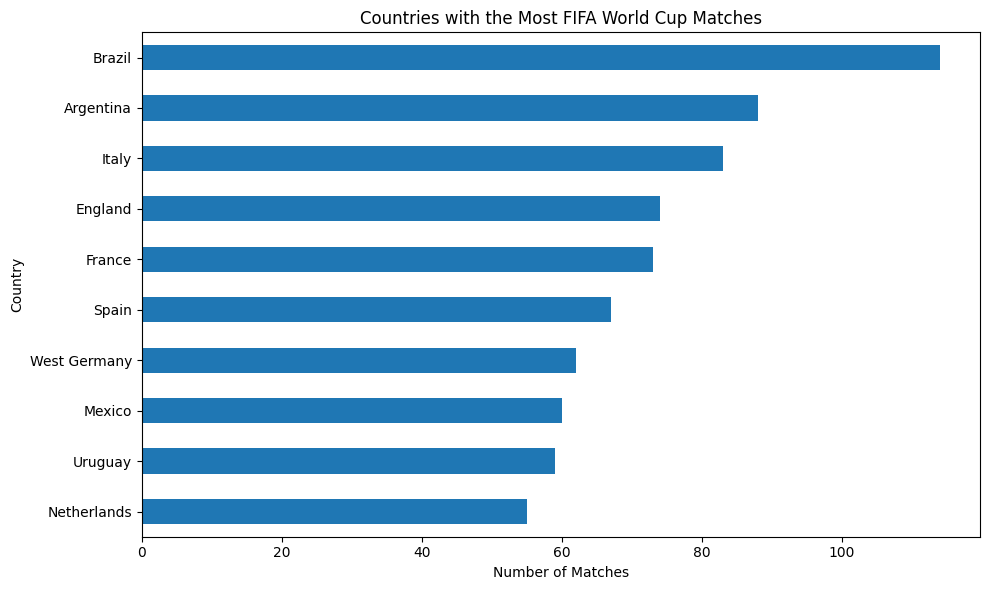

In [16]:
plt.figure(figsize=(10, 6))

top_10_teams.sort_values().plot(kind="barh")

plt.title("Countries with the Most FIFA World Cup Matches")
plt.xlabel("Number of Matches")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

**Analytical Question:** Which countries have participated in the greatest number of World Cup matches?

A horizontal bar chart was selected because it is easier to compare with the number of matches played by countries across the world. The horizontal bar chart also is the easiest to read all the country names. Brazil has participated in the most World Cup matches with 114, followed by Argentina wiht 88 and Italy with 83. Brazil stands out with a considerable lead over all the other countries. 

### Vizualization 2

In [17]:
avg_goals_year = df.groupby("Year")["TotalGoals"].mean()
avg_goals_year

Year
1930    3.888889
1934    4.117647
1938    4.666667
1950    4.000000
1954    5.384615
1958    3.600000
1962    2.781250
1966    2.781250
1970    2.968750
1974    2.552632
1978    2.684211
1982    2.807692
1986    2.538462
1990    2.211538
1994    2.711538
1998    2.671875
2002    2.515625
2006    2.296875
2010    2.265625
2014    2.671875
2018    2.640625
2022    2.687500
Name: TotalGoals, dtype: float64

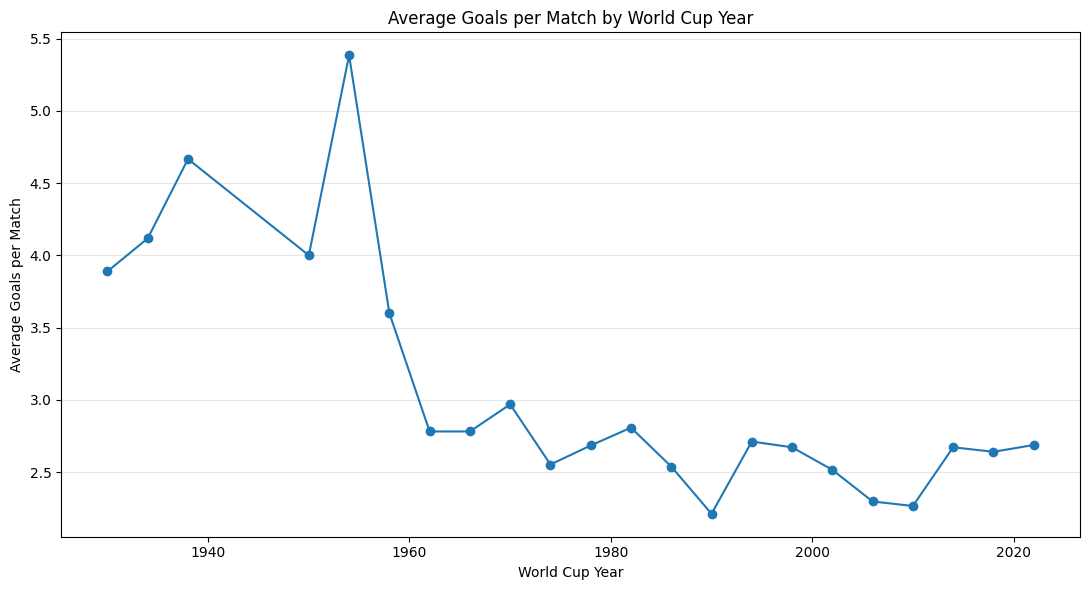

In [18]:
plt.figure(figsize=(11, 6))

plt.plot(
    avg_goals_year.index,
    avg_goals_year.values,
    marker="o"
)

plt.title("Average Goals per Match by World Cup Year")
plt.xlabel("World Cup Year")
plt.ylabel("Average Goals per Match")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Analytical Question:** How has the average number of goals scored per match changed across World Cup tournaments over time? 

A line chart was selected because it clearly displays change in the average goal scoring over time. The chart shows that the early World Cup tournaments generally had a higher score per match, for instance, 1954 reaching the highest average at approximately 5.38 goals per match. After this, scoring declined and became more consistent generally being around 2 or three goals per match in more recent tournaments. The lowest average occured in 1990 at approximately 2.21 goals per match. This visualization helps analysts understand how scoring patterns have changed through World Cup history. 

### Visualization 3

In [19]:
df["TotalGoals"].value_counts().sort_index()

TotalGoals
0      78
1     182
2     203
3     209
4     127
5      81
6      36
7      28
8      10
9       5
10      1
11      3
12      1
Name: count, dtype: int64

In [20]:
df["TotalGoals"].describe()

count    964.000000
mean       2.821577
std        1.927371
min        0.000000
25%        1.000000
50%        3.000000
75%        4.000000
max       12.000000
Name: TotalGoals, dtype: float64

In [21]:
df.nlargest(5, "TotalGoals")[
    ["Year", "HomeTeam", "AwayTeam", "HomeGoals", "AwayGoals", "TotalGoals"]
]

,Year,HomeTeam,AwayTeam,HomeGoals,AwayGoals,TotalGoals
93,1954,Austria,Switzerland,7,5,12
40,1938,Brazil,Poland,6,5,11
87,1954,Hungary,West Germany,8,3,11
312,1982,Hungary,El Salvador,10,1,11
104,1958,France,Paraguay,7,3,10


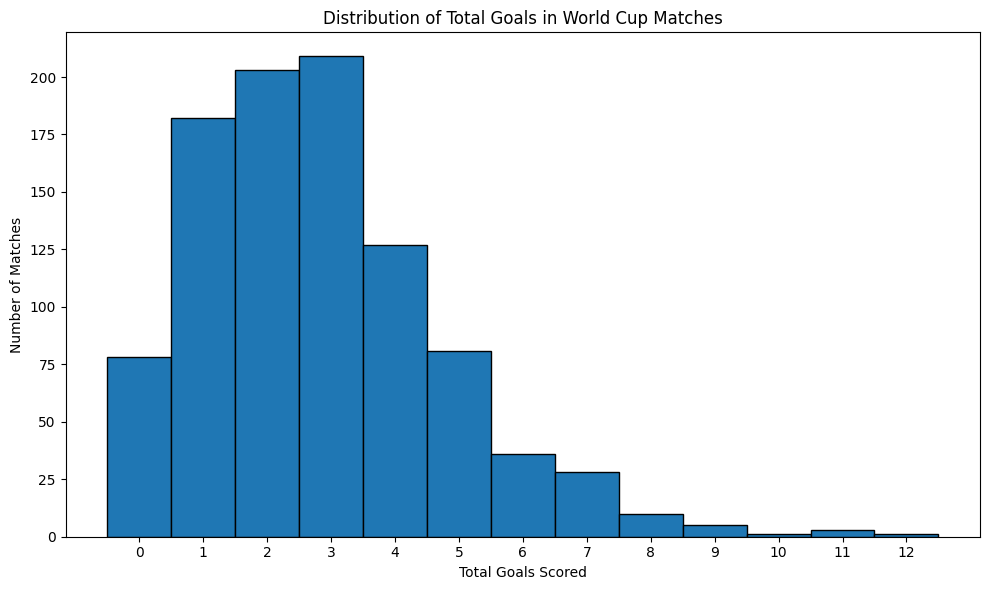

In [22]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["TotalGoals"],
    bins=range(0, df["TotalGoals"].max() + 2),
    edgecolor="black",
    align="left"
)

plt.title("Distribution of Total Goals in World Cup Matches")
plt.xlabel("Total Goals Scored")
plt.ylabel("Number of Matches")

plt.xticks(range(0, df["TotalGoals"].max() + 1))
plt.tight_layout()
plt.show()

**Analytical Question:** What is the distribution of total goals scored in World Cup matches, and are there noticeable high-scoring outliers?

A histogram was selected because it clearly shows the frequency and distribution of total goals scored per match. Most World Cup matches between 1 and 4 total goals, with 3 goals being the most common. The distribution is right-skewed, meaning that very high-scoring matches are uncommon. Extreme matches reached 10 or more total goals, including the 1954 match between Austria and Switzerland that ended 7-5 with a total of 12 goals. This visualization helps us distinguish World Cup from unusual high-scoring matches

### Visualization 4 -- Box Plot

In [23]:
df[["HomeGoals", "AwayGoals"]].describe()

,HomeGoals,AwayGoals
count,964.000000,964.000000
mean,1.766598,1.054979
std,1.601040,1.071720
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,3.000000,2.000000
max,10.000000,7.000000


In [24]:
print("Average Home Goals:", df["HomeGoals"].mean())
print("Average Away Goals:", df["AwayGoals"].mean())

print("Median Home Goals:", df["HomeGoals"].median())
print("Median Away Goals:", df["AwayGoals"].median())

Average Home Goals: 1.766597510373444
Average Away Goals: 1.0549792531120332
Median Home Goals: 1.0
Median Away Goals: 1.0


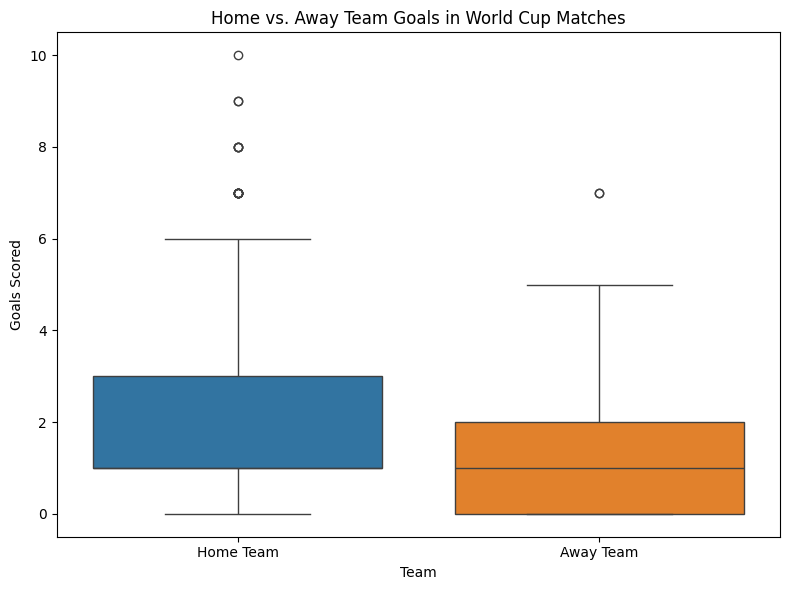

In [25]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=df[["HomeGoals", "AwayGoals"]])

plt.title("Home vs. Away Team Goals in World Cup Matches")
plt.xlabel("Team")
plt.ylabel("Goals Scored")

plt.xticks([0, 1], ["Home Team", "Away Team"])

plt.tight_layout()
plt.show()

**Analytical Question:** How does home-team scoring compare to away-team scoring in World Cup matches?

A box plot was selected because it allows the scoring distributions, medians, spread, and the outliers of home and away teams being compared. Both groups have a median of 1 goal, but the home teams approximately 1.77 goals compared to 1.05 for away teams. The home team scores have a higher outlier number than the away team.

### Visualization 5 

In [26]:
df["StageType"].value_counts()

StageType
Group Stage       718
Knockout Stage    246
Name: count, dtype: int64

In [27]:
stage_goals = (
    df.groupby("StageType")["TotalGoals"]
    .agg(["mean","count"])
    .sort_values("mean", ascending=False)
)

stage_goals

,mean,count
StageType,,
Knockout Stage,3.199187,246
Group Stage,2.692201,718


In [28]:
df["Stage"].value_counts()

Stage
Group Stage           676
Round Of 16            97
Quarter-Finals         70
Semi-Finals            38
Second Group Stage     36
Final                  21
Third-Place Match      20
Final Round             6
Name: count, dtype: int64

In [29]:
stage_detail = (
    df.groupby("Stage")["TotalGoals"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

stage_detail

,mean,count
Stage,,
Final Round,5.166667,6
Final,3.809524,21
Third-Place Match,3.800000,20
Semi-Finals,3.473684,38
Round Of 16,3.123711,97
Quarter-Finals,2.800000,70
Group Stage,2.674556,676
Second Group Stage,2.611111,36


In [30]:
stage_plot = stage_detail.sort_values("mean")

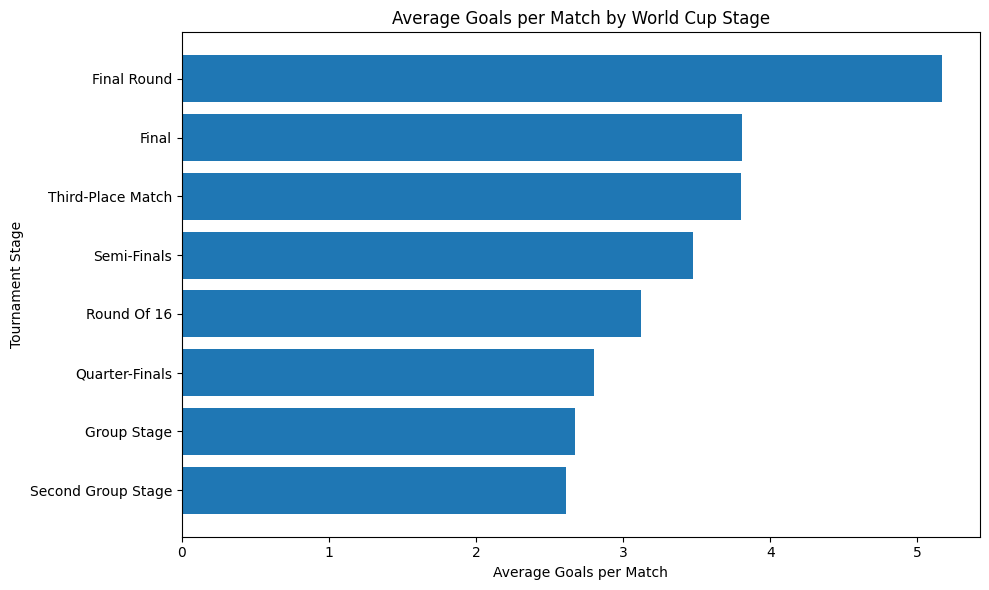

In [31]:
plt.figure(figsize=(10, 6))

plt.barh(
    stage_plot.index,
    stage_plot["mean"]
)

plt.title("Average Goals per Match by World Cup Stage")
plt.xlabel("Average Goals per Match")
plt.ylabel("Tournament Stage")

plt.tight_layout()
plt.show()

**Analytical Question:** Which World Cup tournament stages have the highest average number of goals per match?

A horizontal bar chart was selected because it allows the scoring averages of different tournament stages to be compared clearly. The Final Round has the highest average at approximately 5.17 goals per match, although this category contains only six matches. Finals and Third-Place Matches also have relatively high averages of about 3.81 and 3.80 goals, while Group Stage matches average about 2.67 goals. This visualization helps identify how scoring differs across tournament stages, while also showing why the number of matches in each stage should be considered when interpreting the averages.

### Visualization 6 -- Interactive chart

In [32]:
city_matches = df["HostCity"].value_counts().head(15)

city_matches

HostCity
Mexico City       23
Al Rayyan         23
Montevideo        18
Guadalajara       17
Rio de Janeiro    15
Johannesburg      15
Doha              15
Moscow            12
Buenos Aires      12
São Paulo         12
Paris             12
León              11
Munich            11
London            10
Stuttgart         10
Name: count, dtype: int64

In [33]:
city_matches = (
    df["HostCity"]
    .value_counts()
    .head(15)
    .reset_index()
)

city_matches.columns = ["HostCity", "Matches"]

In [34]:
city_matches.head()

,HostCity,Matches
0,Mexico City,23
1,Al Rayyan,23
2,Montevideo,18
3,Guadalajara,17
4,Rio de Janeiro,15


In [35]:
fig = px.bar(
    city_matches,
    x="Matches",
    y="HostCity",
    orientation="h",
    title="Top 15 Cities Hosting FIFA World Cup Matches",
    labels={
        "Matches": "Number of Matches",
        "HostCity": "Host City"
    }
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"}
)

fig.show()

**Analytical Question:** Which cities have hosted the greatest number of World Cup matches?

An interactive horizontal bar chart was selected because it makes it easy to compare host cities while allowing users to hover over each bar for additional information. Mexico City and Al Rayyan have hosted the most matches in the dataset with 23 each, followed by Montevideo with 18 and Guadalajara with 17. The visualization shows that World Cup matches have been concentrated in several major host cities. The interactive format allows executives, journalists, and fans to explore the results more directly.

## **Visualization Evaluation**

Of the six visualizations created, the line chart showing Average Goals per Match by World Cup Year was the most effective. The chart clearly communicates how the scoring patterns change throughout World Cup history. Because the data is organized chronologically, the connected points make it easy to gollow the changes from one tournament to the next. One of the most noticeable patterns is the higher scoring during the earlier tournaments. The 1954 World Cup had the highest average of approximately 5.38 goals per match. After this period, scoring generally declined and became more stable, usually remaining between two and three goals per match. However, the 1990 tournament has the lowest average at about 2.21 goals per match.

A line chart is more appropriate for this question than alternatives such as a bar chart, histogram, or scatterplot. A bar chart could compare the individual tournament averages, but it would place more emphasis on each individual year rather than the overall historical trend. A histogram would show the distribution of scoring averages but would remove the chronological relationship between tournaments. A scatterplot could display the individual observations, but connecting the tournament years with a line makes the direction and magnitude of changes easier to follow.

Several visualization design principles also make this chart effective. Clarity and simplicity were maintained by limiting the visualization to one primary variable and avoiding unnecessary visual elements. Clearly labeled axes allow the viewer to quickly understand that tournament year is being compared with average goals per match. Markers were included on the line to distinguish the individual World Cup tournaments, while horizontal gridlines make it easier to estimate and compare scoring averages. The chart also avoids unnecessary colors and legends because only one data series is being displayed.

Overall, the visualization effectively communicates both individual tournament differences and the broader historical scoring trend. This makes it useful for analysts, journalists, and fans who want to quickly understand how World Cup scoring has evolved over time.

## Conclusion

This analysis used historical FIFA World Cup match data to examine participation, scoring trends, scoring distributions, tournament stages, and host cities. Brazil had the greatest number of match appearances, while early World Cup tournaments generally had higher scoring averages than more recent tournaments. Most matches contained relatively few goals, although several extreme high-scoring matches were identified. Home teams had a higher average number of goals than away teams, despite both having a median of one goal. Scoring also varied across tournament stages, and several cities stood out for hosting large numbers of matches. Together, these visualizations demonstrate how different chart types can reveal patterns, trends, distributions, comparisons, and outliers within the same dataset.